In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
import corner

scale = 1.1
scale_sim = 1.0

data = np.loadtxt('results/delta_beta.txt', usecols=(3, 4, 1, 2, 0))

idx = 15

data[:idx,0] /= scale
data[:idx,1] /= scale

idx = 21
data_lit = data[:idx]
data_meas = data[idx:]

sim = np.loadtxt('results/simulation.txt', usecols=(0, 1, 2))

sim[:,1] *= scale_sim

# Uncertainties
energy_mean = 30.0 # MeV
beta_mean = 0.067
stopping_power_err = 0.03  # 3% uncertainty
sauron_gain_err = 0.02     # 2% uncertainty

# The beta is calculated as beta = sqrt(2*E/mc^2), thus propagate error
m0c2_O15 = 15.003065 * 931.494  # MeV
energy_total = energy_mean + m0c2_O15
beta_gain_err = (m0c2_O15**2 / (energy_total**3 * beta_mean)) * (energy_mean * sauron_gain_err)

print(f"Beta: {beta_mean} +/- {beta_gain_err} (% = {100*beta_gain_err/beta_mean} )")

Beta: 0.067 +/- 0.000636681979902529 (% = 0.9502716117948192 )


Simulation fit: slope = 10576.00 ± 317.28
Simulation prior: slope = 10576.00 ± 317.28
Running MCMC with 32 walkers, 4 dimensions...
Burn-in: 1000 steps...


100%|██████████| 1000/1000 [00:00<00:00, 1467.30it/s]


Production: 3000 steps...


100%|██████████| 3000/3000 [00:01<00:00, 1588.75it/s]



=== RESULTS ===
slope: 10358.19 + 286.58 - 295.10
intercept: -0.30 + 0.21 - 0.20
lifetime_1: 0.60 + 0.31 - 0.29
lifetime_2: 0.08 + 0.13 - 0.06


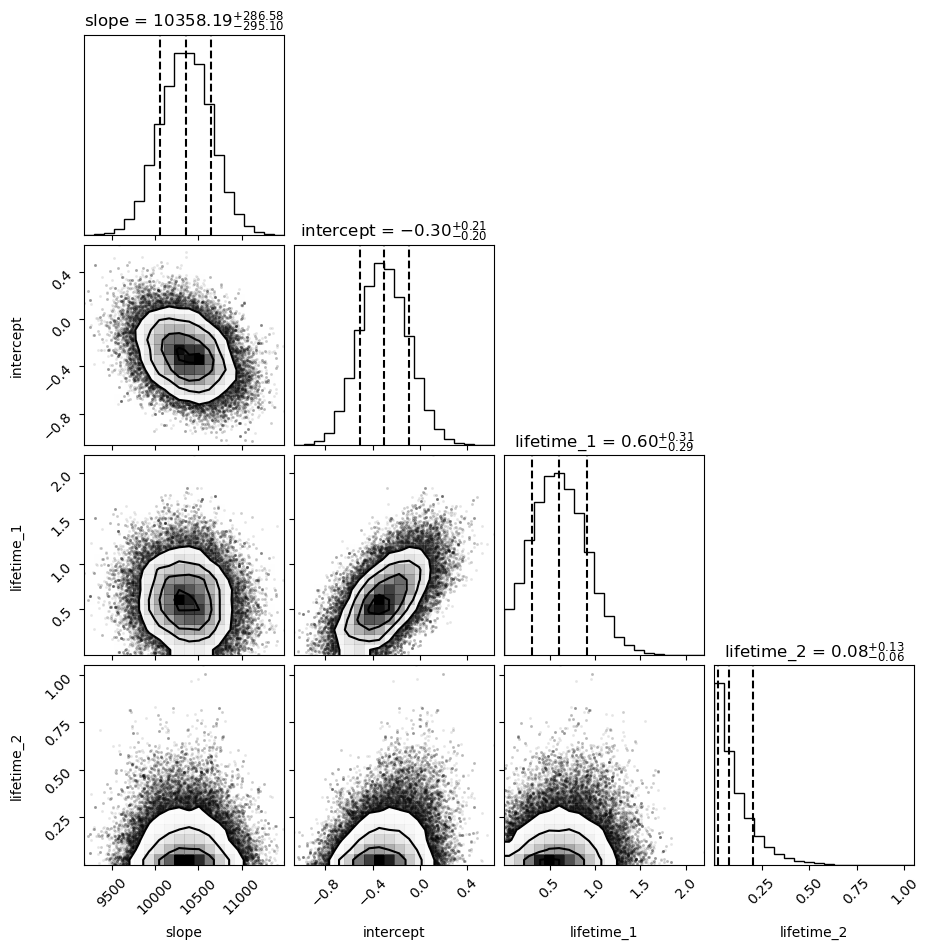

In [2]:
    
# Parameters: [slope, intercept, lifetime_state1, lifetime_state2, ...]
# We'll have 2 + n_measured_states parameters
n_meas = len(data_meas)
n_params = 2 + n_meas

# Simulation provides prior on the slope
def linear_func(x, a, b):
    return a * x + b

# Fit simulation to get prior
popt_sim, pcov_sim = curve_fit(linear_func, sim[:,1], sim[:,0], 
                                 sigma=sim[:,2], absolute_sigma=True)
sim_slope_mean = popt_sim[0]
sim_slope_std = stopping_power_err * popt_sim[0]
delta_beta_shift = 0
delta_beta_sigma = beta_gain_err

# Calculate intercept uncertainty from delta_beta
intercept_sigma_from_delta_beta = abs(sim_slope_mean) * delta_beta_sigma

print(f"Simulation fit: slope = {sim_slope_mean:.2f} ± {sim_slope_std:.2f}")

print(f"Simulation prior: slope = {sim_slope_mean:.2f} ± {sim_slope_std:.2f}")

def log_prior(theta):
    """Prior probability"""
    slope, intercept = theta[:2]
    lifetimes = theta[2:]
    
    # Gaussian prior on slope and intercept from simulation
    log_p_slope = -0.5 * ((slope - sim_slope_mean) / sim_slope_std)**2
    log_p_intercept = -0.5 * ((intercept - delta_beta_shift * slope) / intercept_sigma_from_delta_beta)**2
    
    # Physical constraint: lifetimes must be positive
    if np.any(lifetimes < 0):
        return -np.inf
    
    # Could add additional priors on lifetimes if needed
    # For now, uniform prior for positive lifetimes
    if np.any(lifetimes > 1000):  # Some reasonable upper limit
        return -np.inf
    
    return log_p_slope + log_p_intercept

def log_likelihood(theta):
    """Likelihood from literature data"""
    slope, intercept = theta[:2]
    lifetimes_meas = theta[2:]
    
    # Chi-square for literature data
    beta_lit = data_lit[:,0]
    beta_lit_err = data_lit[:,1]
    lifetime_lit = data_lit[:,2]
    lifetime_lit_err = data_lit[:,3]

    # Add error from delta beta to the literature uncertainty
    lifetime_lit_err_total = np.sqrt(lifetime_lit_err**2 + (slope * beta_lit_err)**2)
    
    model_lit = linear_func(beta_lit, slope, intercept)
    chi2_lit = np.sum(((lifetime_lit - model_lit) / lifetime_lit_err_total)**2)
    
    # Chi-square for measured states
    # For each measured state, we have beta and predicted lifetime
    beta_meas = data_meas[:,0]
    beta_meas_err = data_meas[:,1]
    
    chi2_meas = 0
    for i in range(n_meas):
        # Predicted lifetime from beta and calibration
        predicted_lifetime = linear_func(beta_meas[i], slope, intercept)
        
        # Uncertainty from beta measurement
        d_lifetime_d_beta = slope
        lifetime_pred_err = d_lifetime_d_beta * beta_meas_err[i]
        
        # Compare with fitted lifetime parameter
        chi2_meas += ((lifetimes_meas[i] - predicted_lifetime) / lifetime_pred_err)**2
    
    return -0.5 * (chi2_lit + chi2_meas)

def log_probability(theta):
    """Posterior probability"""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# Initial guess from curve_fit on literature data
popt_init, _ = curve_fit(linear_func, data_lit[:,0], data_lit[:,2], 
                          sigma=data_lit[:,3], absolute_sigma=True)

# Initialize walkers
n_walkers = 32
n_dim = n_params

# Starting positions: add small scatter around initial guess
pos = np.zeros((n_walkers, n_dim))
pos[:, 0] = popt_init[0] + 500 * np.random.randn(n_walkers)  # slope
pos[:, 1] = popt_init[1] + 2 * np.random.randn(n_walkers)    # intercept

# Initialize lifetimes from the linear prediction
for i in range(n_meas):
    beta = data_meas[i, 0]
    lifetime_init = linear_func(beta, *popt_init)
    # Start with positive values
    if lifetime_init < 0:
        pos[:, 2+i] = 5 * np.abs(np.random.randn(n_walkers))
    else:
        pos[:, 2+i] = lifetime_init + 5 * np.abs(np.random.randn(n_walkers))

# Run MCMC
print(f"Running MCMC with {n_walkers} walkers, {n_dim} dimensions...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability)

# Burn-in
n_burn = 1000
print(f"Burn-in: {n_burn} steps...")
state = sampler.run_mcmc(pos, n_burn, progress=True)
sampler.reset()

# Production run
n_steps = 3000
print(f"Production: {n_steps} steps...")
sampler.run_mcmc(state, n_steps, progress=True)

# Get samples
samples = sampler.get_chain(flat=True)

# Compute statistics
param_names = ['slope', 'intercept']
for i in range(n_meas):
    param_names.append(f'lifetime_{i+1}')

print("\n=== RESULTS ===")
for i, name in enumerate(param_names):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{name}: {mcmc[1]:.2f} + {q[1]:.2f} - {q[0]:.2f}")

# Get best-fit parameters (median)
coeffs = np.median(samples[:, :2], axis=0)
coeffs_err = np.std(samples[:, :2], axis=0)

lifetimes_best = np.median(samples[:, 2:], axis=0)
lifetimes_err = np.std(samples[:, 2:], axis=0)

# Plot corner plot
fig_corner = corner.corner(samples, labels=param_names, 
                            quantiles=[0.16, 0.5, 0.84],
                            show_titles=True, title_kwargs={"fontsize": 12})
plt.savefig('plots/corner_plot.png', dpi=300)
plt.show()


Beta: 0.000087 ± 0.000024, Lifetime: 0.60 ± 0.30 fs

Beta: -0.000038 ± 0.000030, Lifetime: 0.08 ± 0.11 fs
  -> Close to zero, 90% CL upper limit: 0.33 fs


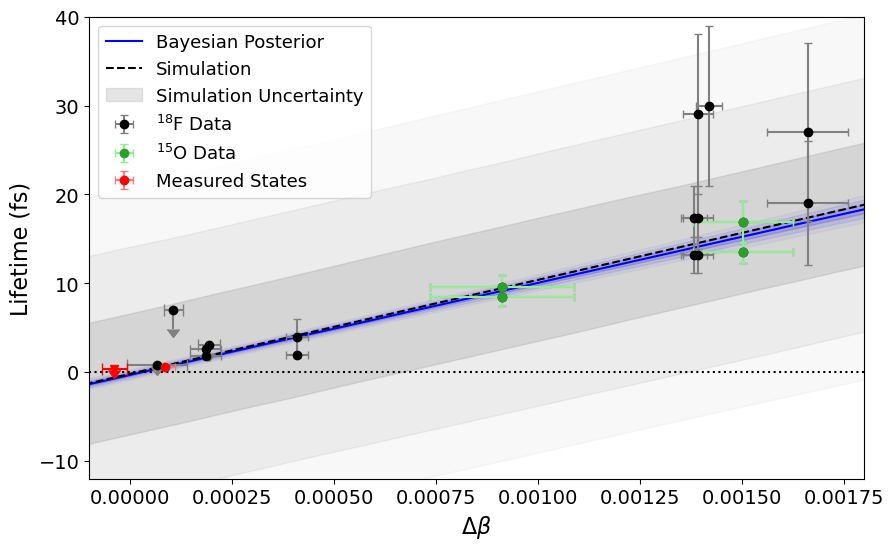

Literature: Beta=0.000408 ± 0.000027, Lifetime=4.00 ± 2.00 fs
Bayesian Prediction: 3.93 + 0.28 fs (68% CI)
Literature: Beta=0.000408 ± 0.000027, Lifetime=1.90 ± 0.30 fs
Bayesian Prediction: 3.93 + 0.28 fs (68% CI)
Literature: Beta=0.000185 ± 0.000039, Lifetime=1.77 ± 0.30 fs
Bayesian Prediction: 1.62 + 0.40 fs (68% CI)
Literature: Beta=0.000185 ± 0.000039, Lifetime=2.55 ± 0.50 fs
Bayesian Prediction: 1.62 + 0.40 fs (68% CI)
Literature: Beta=0.001661 ± 0.000099, Lifetime=19.00 ± 7.00 fs
Bayesian Prediction: 16.90 + 1.02 fs (68% CI)
Literature: Beta=0.001661 ± 0.000099, Lifetime=27.00 ± 10.00 fs
Bayesian Prediction: 16.90 + 1.02 fs (68% CI)
Literature: Beta=0.001393 ± 0.000036, Lifetime=13.20 ± 2.00 fs
Bayesian Prediction: 14.12 + 0.37 fs (68% CI)
Literature: Beta=0.001393 ± 0.000036, Lifetime=17.40 ± 3.60 fs
Bayesian Prediction: 14.12 + 0.37 fs (68% CI)
Literature: Beta=0.001393 ± 0.000036, Lifetime=29.00 ± 9.00 fs
Bayesian Prediction: 14.12 + 0.37 fs (68% CI)
Literature: Beta=0.001383 

In [3]:
# ============= PLOTTING =============
plt.figure(figsize=(10,6))


# Plot literature data
# Separate upper limits from normal data
mask_ul = data_lit[:-2, 3] == data_lit[:-2, 2]  # error == value means upper limit
mask_normal = ~mask_ul

# Mask the 1680 and 5180 points and plot them green
mask_15o = (data_lit[:-2,4] == 1680) | (data_lit[:-2,4] == 5180)

# 18F data with error bars
plt.errorbar(data_lit[:-2,0][mask_normal], data_lit[:-2,2][mask_normal],
             xerr=data_lit[:-2,1][mask_normal], yerr=data_lit[:-2,3][mask_normal],
             fmt='o', label='$^{18}$F Data', color='black', ecolor='gray',
             capsize=3, zorder=10)

# 15O data with error bars
plt.errorbar(data_lit[:-2,0][mask_15o], data_lit[:-2,2][mask_15o],
             xerr=data_lit[:-2,1][mask_15o], yerr=data_lit[:-2,3][mask_15o],
             fmt='o', label='$^{15}$O Data', color='tab:green', ecolor='lightgreen', capsize=3, zorder=10)

# Upper limits (downward arrows)
plt.errorbar(data_lit[:-2,0][mask_ul], data_lit[:-2,2][mask_ul],
             xerr=data_lit[:-2,1][mask_ul],
             fmt='o', color='black',
             uplims=True, yerr=data_lit[:-2,2][mask_ul]*0.3,
             ecolor='gray', capsize=4, zorder=10)
#plt.errorbar(data_lit[-2:,0], data_lit[-2:,2], xerr=data_lit[-2:,1], 
#             yerr=data_lit[-2:,3], fmt='o', label='Literature $^{15}$O', 
#             color='green', ecolor='lightgreen', capsize=3, zorder=10)


# Plot fit with uncertainty bands
x_fit = np.linspace(-5e-4, 0.003, 100)


# Plot samples from posterior
y_samples = []
for _ in range(100):
    idx = np.random.randint(len(samples))
    y_samples.append(samples[idx, 0] * x_fit + samples[idx, 1])
y_samples = np.array(y_samples)


y_fit = np.median(y_samples, axis=0)
y_fit_err = np.std(y_samples, axis=0)
pcov_for_plot = np.cov(samples[:, :2].T)


plt.plot(x_fit, y_fit, label='Bayesian Posterior', color='blue')
plt.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err, 
                 color='blue', alpha=0.2)
plt.fill_between(x_fit, y_fit - y_fit_err * 2, y_fit + y_fit_err * 2, 
                 color='blue', alpha=0.1)
plt.fill_between(x_fit, y_fit - y_fit_err * 3, y_fit + y_fit_err * 3, 
                 color='blue', alpha=0.05)


# Plot results for measured states
for i in range(len(data_meas)):
    beta = data_meas[i,0]
    beta_err = data_meas[i,1]
    lifetime = lifetimes_best[i]
    lifetime_err = lifetimes_err[i]
    print(f'\nBeta: {beta:.6f} ± {beta_err:.6f}, Lifetime: {lifetime:.2f} ± {lifetime_err:.2f} fs')
    
    if lifetime < lifetime_err * 2:  # Close to zero or negative within uncertainty
        from scipy.stats import norm
        z_95 = norm.ppf(0.95)
        upper_limit = np.percentile(samples[:, 2+i], 95)  # 90% upper limit from posterior
        print(f'  -> Close to zero, 90% CL upper limit: {upper_limit:.2f} fs')
        yerr = [[20, 0]]
        yerr = np.array(yerr).T
        plt.errorbar(beta, upper_limit, xerr=beta_err,
                     fmt='v', label='90% CL Upper Limit' if i==0 else None,
                     color='red', uplims=True, yerr=upper_limit*0.3,
                     ecolor='red', capsize=4, zorder=10)
    
    else:
        plt.errorbar(beta, lifetime, xerr=beta_err, yerr=lifetime_err,
                     fmt='o', label='Measured States' if i==0 else None,
                     color='red', ecolor='lightcoral', capsize=3, zorder=10)


# Plot simulation line
popt_sim, pcov_sim = curve_fit(linear_func, sim[:,1], sim[:,0], 
                                sigma=sim[:,2], absolute_sigma=True)
grid = np.linspace(-5e-4, 0.003, 100)
plt.plot(grid, linear_func(grid, *popt_sim), color='black', 
         linestyle='--', label='Simulation')

# Calculate simulation uncertainty from intercept and slope uncertainties
# You must sample slop in 5% region and the delta beta in 5e-4 gaussian and calculate percentiles
slope_samples = np.random.normal(popt_sim[0], stopping_power_err * abs(popt_sim[0]), 1000)
delta_beta_samples = np.random.normal(0, beta_gain_err, 1000)
intercept_samples = delta_beta_samples * slope_samples

# Calculate percentiles for uncertainty band
sim_y_samples = np.array([linear_func(grid, slope, intercept) 
                          for slope, intercept in zip(slope_samples, intercept_samples)])
sim_y_lower = np.percentile(sim_y_samples, 16, axis=0)
sim_y_upper = np.percentile(sim_y_samples, 84, axis=0)
sim_y_lower_2sigma = np.percentile(sim_y_samples, 2.5, axis=0)
sim_y_upper_2sigma = np.percentile(sim_y_samples, 97.5, axis=0)
sim_y_lower_3sigma = np.percentile(sim_y_samples, 0.15, axis=0)
sim_y_upper_3sigma = np.percentile(sim_y_samples, 99.85, axis=0)

plt.fill_between(grid, sim_y_lower, sim_y_upper,
                 color='gray', alpha=0.2, label='Simulation Uncertainty')
plt.fill_between(grid, sim_y_lower_2sigma, sim_y_upper_2sigma,
                 color='gray', alpha=0.1)
plt.fill_between(grid, sim_y_lower_3sigma, sim_y_upper_3sigma,
                 color='gray', alpha=0.05)


# Plot labels
data_sorted = data[np.argsort(data[:,0])]
for i in range(len(data_sorted)):
    if i % 2 == 0:
        offset = data_sorted[i,3] * 1.6
    else:
        offset = data_sorted[i,3] * -1.6
    if data_sorted[i,4] == 6180:
        offset = 11
    if data_sorted[i,4] == 6790:
        offset = 9
    #plt.text(data_sorted[i,0], data_sorted[i,2] + offset, 
    #         f'{int(data_sorted[i,4])} keV', ha='center', va='center')

plt.xlabel('$\\Delta \\beta$', fontsize=16)
plt.ylabel('Lifetime (fs)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(-1e-4, 0.0018)
plt.ylim(-12, 40)
#plt.xlim(0, 0.002)
plt.axhline(0, color='black', linestyle=':')
plt.legend(fontsize=13, ncol=1, loc='upper left')
plt.savefig('plots/beta_lifetime_fit.png', dpi=300)
plt.show()

# Using the Bayesian posterior, calculate the predicted lifetime for each point in the literature and compare with literature values
for i in range(len(data_lit)-2):
    beta = data_lit[i,0]
    beta_err = data_lit[i,1]
    lifetime_lit = data_lit[i,2]
    lifetime_lit_err = data_lit[i,3]
    
    # Calculate predicted lifetime for each sample in the posterior
    predicted_lifetimes = samples[:, 0] * beta + samples[:, 1]
    predicted_lifetimes_lower = samples[:, 0] * (beta - beta_err) + samples[:, 1]
    
    # Calculate median and 68% credible interval
    pred_median = np.median(predicted_lifetimes)
    pred_lower = np.median(predicted_lifetimes_lower)

    pred_sigma = np.abs(pred_median - pred_lower)
    
    print(f'Literature: Beta={beta:.6f} ± {beta_err:.6f}, Lifetime={lifetime_lit:.2f} ± {lifetime_lit_err:.2f} fs')
    print(f'Bayesian Prediction: {pred_median:.2f} + {pred_sigma:.2f} fs (68% CI)')

In [ ]:
# Save the samples of last parameter to file
np.savetxt('results/lifetime_samples.txt', samples[:, 2:], comments='')